# Hate Speech & Toxicity Detection using Machine Learning & Deep Learning

This notebook implements and compares **four models** for detecting hate speech and toxic content on the Jigsaw Toxic Comment Classification Challenge dataset.

**Pipeline:** Data loading → Preprocessing → Feature engineering → Train 4 models → Evaluate → Compare.

**Models compared**

1. Logistic Regression (TF-IDF) — baseline
2. Linear SVM (TF-IDF) — strong traditional baseline
3. LSTM (learned embeddings) — captures sequence
4. BiLSTM (learned embeddings) — bidirectional context

**Classes (3-class scheme):** `non_toxic`, `toxic`, `abusive` — derived from the original Jigsaw labels.

---


## 1. Setup & Imports

In [2]:
# If running on Colab, uncomment to install:
# !pip install -q scikit-learn nltk tensorflow matplotlib seaborn pandas

import os
import re
import string
import random
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore")

# ---- Reproducibility ----
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
os.environ["PYTHONHASHSEED"] = str(SEED)

try:
    import tensorflow as tf
    tf.random.set_seed(SEED)
    print("TensorFlow:", tf.__version__)
except ImportError:
    print("TensorFlow not installed — deep learning sections will be skipped.")


TensorFlow: 2.19.0


In [3]:
import nltk
for pkg in ["stopwords", "wordnet", "punkt", "punkt_tab", "omw-1.4"]:
    try:
        nltk.download(pkg, quiet=True)
    except Exception:
        pass

from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize

STOPWORDS = set(stopwords.words("english"))
LEMMATIZER = WordNetLemmatizer()
print("NLTK ready. Stopword count:", len(STOPWORDS))


NLTK ready. Stopword count: 198


## 2. Data Loading

We use the **Jigsaw Toxic Comment Classification Challenge** dataset
(<https://www.kaggle.com/c/jigsaw-toxic-comment-classification-challenge>).

Place `train.csv` (the labelled file) inside a `./data/` folder next to this notebook.
The file has columns: `id`, `comment_text`, `toxic`, `severe_toxic`, `obscene`, `threat`, `insult`, `identity_hate`.


In [4]:
DATA_PATH = "/content/train.csv"  # change if your file lives elsewhere

if not os.path.exists(DATA_PATH):
    raise FileNotFoundError(
        f"Could not find {DATA_PATH}. Download the Jigsaw "
        "'train.csv' from Kaggle and place it in ./data/."
    )

df = pd.read_csv(DATA_PATH, engine='python', on_bad_lines='skip')
print("Shape:", df.shape)
df.head()


Shape: (21825, 8)


,id,comment_text,toxic,severe_toxic,obscene,threat,insult,identity_hate
0,0000997932d777bf,Explanation\nWhy the edits made under my usern...,0,0,0,0,0,0
1,000103f0d9cfb60f,D'aww! He matches this background colour I'm s...,0,0,0,0,0,0
2,000113f07ec002fd,"Hey man, I'm really not trying to edit war. It...",0,0,0,0,0,0
3,0001b41b1c6bb37e,"""\nMore\nI can't make any real suggestions on ...",0,0,0,0,0,0
4,0001d958c54c6e35,"You, sir, are my hero. Any chance you remember...",0,0,0,0,0,0


### 2.1 Map original 6 binary labels → 3 mutually-exclusive classes

The Jigsaw dataset uses six binary labels per comment. We collapse them into a
single 3-class label so the task is a clean multi-class classification:

| Class | Rule |
|-------|------|
| `abusive` (2) | `severe_toxic`, `threat`, `insult`, or `identity_hate` is 1 |
| `toxic` (1)   | `toxic` or `obscene` is 1 (and not abusive) |
| `non_toxic` (0) | none of the above |


label
non_toxic    19576
abusive       1192
toxic         1057
Name: count, dtype: int64


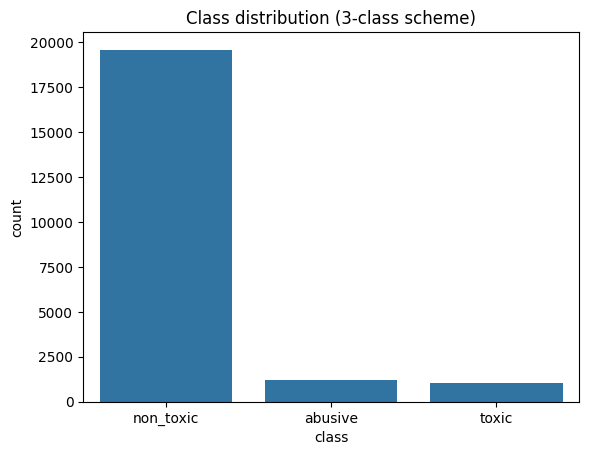

In [5]:
LABEL_COLS = ["toxic", "severe_toxic", "obscene", "threat", "insult", "identity_hate"]

def map_label(row):
    if row["severe_toxic"] or row["threat"] or row["insult"] or row["identity_hate"]:
        return 2  # abusive
    if row["toxic"] or row["obscene"]:
        return 1  # toxic
    return 0      # non_toxic

df["label"] = df[LABEL_COLS].apply(map_label, axis=1)
CLASS_NAMES = ["non_toxic", "toxic", "abusive"]

print(df["label"].value_counts().rename(index=dict(enumerate(CLASS_NAMES))))
sns.countplot(x=df["label"].map(dict(enumerate(CLASS_NAMES))))
plt.title("Class distribution (3-class scheme)")
plt.xlabel("class")
plt.ylabel("count")
plt.show()


**Imbalance note.** The dataset is heavily skewed toward `non_toxic`, so we
will rely on **macro-F1** in addition to accuracy to compare models fairly.

## 3. Text Preprocessing

Steps applied to every comment:

1. lowercase
2. strip URLs, user mentions, HTML tags, digits
3. remove punctuation
4. tokenize
5. drop English stopwords
6. lemmatize


In [6]:
URL_RE = re.compile(r"http\S+|www\.\S+")
MENTION_RE = re.compile(r"@\w+")
HTML_RE = re.compile(r"<.*?>")
NUM_RE = re.compile(r"\d+")
PUNCT_TABLE = str.maketrans("", "", string.punctuation)

def clean_text(text: str) -> str:
    text = str(text).lower()
    text = URL_RE.sub(" ", text)
    text = MENTION_RE.sub(" ", text)
    text = HTML_RE.sub(" ", text)
    text = NUM_RE.sub(" ", text)
    text = text.translate(PUNCT_TABLE)
    text = re.sub(r"\s+", " ", text).strip()
    return text

def preprocess(text: str) -> str:
    cleaned = clean_text(text)
    tokens = word_tokenize(cleaned)
    tokens = [LEMMATIZER.lemmatize(t) for t in tokens
              if t not in STOPWORDS and len(t) > 1]
    return " ".join(tokens)

# Quick sanity check
sample = "Check this out @user!!! https://x.com/abc <br>Visit NOW 12345..."
print("Raw     :", sample)
print("Cleaned :", preprocess(sample))


Raw     : Check this out @user!!! https://x.com/abc <br>Visit NOW 12345...
Cleaned : check visit


In [7]:
# Apply to the full dataset (this can take a couple of minutes)
df["clean_text"] = df["comment_text"].astype(str).map(preprocess)
df = df[df["clean_text"].str.len() > 0].reset_index(drop=True)
print("After preprocessing:", df.shape)
df[["comment_text", "clean_text", "label"]].head()


After preprocessing: (21814, 10)


,comment_text,clean_text,label
0,Explanation\nWhy the edits made under my usern...,explanation edits made username hardcore metal...,0
1,D'aww! He matches this background colour I'm s...,daww match background colour im seemingly stuc...,0
2,"Hey man, I'm really not trying to edit war. It...",hey man im really trying edit war guy constant...,0
3,"""\nMore\nI can't make any real suggestions on ...",cant make real suggestion improvement wondered...,0
4,"You, sir, are my hero. Any chance you remember...",sir hero chance remember page thats,0


## 4. Train / Validation / Test split

Stratified 70 / 15 / 15 split on the 3-class label so all models see exactly the
same data.


In [8]:
from sklearn.model_selection import train_test_split

X = df["clean_text"].values
y = df["label"].values

X_trainval, X_test, y_trainval, y_test = train_test_split(
    X, y, test_size=0.15, stratify=y, random_state=SEED
)
val_relative = 0.15 / 0.85
X_train, X_val, y_train, y_val = train_test_split(
    X_trainval, y_trainval, test_size=val_relative,
    stratify=y_trainval, random_state=SEED
)

print(f"Train: {len(X_train):>7}   Val: {len(X_val):>6}   Test: {len(X_test):>6}")


Train:   15269   Val:   3272   Test:   3273


## 5. Feature Engineering

* **Traditional ML (Logistic Regression, SVM):** TF-IDF on uni- and bi-grams.
* **Deep models (LSTM, BiLSTM):** integer tokenization + padding + a learned
  embedding layer.


In [9]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(
    max_features=30_000,
    ngram_range=(1, 2),
    min_df=2,
    sublinear_tf=True,
)
X_train_tfidf = tfidf.fit_transform(X_train)
X_val_tfidf = tfidf.transform(X_val)
X_test_tfidf = tfidf.transform(X_test)

print("TF-IDF train shape:", X_train_tfidf.shape)


TF-IDF train shape: (15269, 30000)


In [10]:
# Tokenizer + padding for the deep learning models
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

VOCAB_SIZE = 30_000
MAX_LEN = 120

tokenizer = Tokenizer(num_words=VOCAB_SIZE, oov_token="<OOV>")
tokenizer.fit_on_texts(X_train)

def to_padded(texts):
    seq = tokenizer.texts_to_sequences(texts)
    return pad_sequences(seq, maxlen=MAX_LEN, padding="post", truncating="post")

X_train_pad = to_padded(X_train)
X_val_pad   = to_padded(X_val)
X_test_pad  = to_padded(X_test)

print("Padded train shape:", X_train_pad.shape)


Padded train shape: (15269, 120)


## 6. Evaluation Helpers

A single `evaluate()` function we call for every model so that the comparison is
strictly apples-to-apples.


In [11]:
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report,
)

results = {}

def evaluate(name, y_true, y_pred, fit_seconds=None):
    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, average="macro", zero_division=0)
    rec = recall_score(y_true, y_pred, average="macro", zero_division=0)
    f1 = f1_score(y_true, y_pred, average="macro", zero_division=0)
    results[name] = {
        "Accuracy": acc, "Precision": prec, "Recall": rec, "F1": f1,
        "TrainTime(s)": fit_seconds,
    }
    print(f"\n=== {name} ===")
    print(classification_report(y_true, y_pred, target_names=CLASS_NAMES, zero_division=0))
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(4, 3))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
    plt.title(f"Confusion matrix — {name}")
    plt.xlabel("Predicted"); plt.ylabel("True")
    plt.tight_layout(); plt.show()


## 7. Model 1 — Logistic Regression (baseline)


=== Logistic Regression ===
              precision    recall  f1-score   support

   non_toxic       0.97      0.96      0.96      2936
       toxic       0.26      0.31      0.28       158
     abusive       0.61      0.68      0.65       179

    accuracy                           0.91      3273
   macro avg       0.61      0.65      0.63      3273
weighted avg       0.92      0.91      0.91      3273



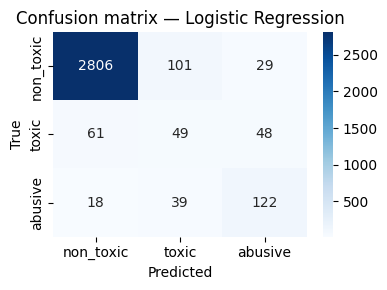

In [12]:
import time
from sklearn.linear_model import LogisticRegression

t0 = time.time()
logreg = LogisticRegression(
    max_iter=1000, C=1.0, class_weight="balanced",
    n_jobs=-1, random_state=SEED,
)
logreg.fit(X_train_tfidf, y_train)
fit_lr = time.time() - t0

y_pred_lr = logreg.predict(X_test_tfidf)
evaluate("Logistic Regression", y_test, y_pred_lr, fit_lr)


## 8. Model 2 — Linear SVM


=== SVM (Linear) ===
              precision    recall  f1-score   support

   non_toxic       0.96      0.99      0.97      2936
       toxic       0.30      0.16      0.21       158
     abusive       0.67      0.64      0.66       179

    accuracy                           0.93      3273
   macro avg       0.65      0.59      0.61      3273
weighted avg       0.91      0.93      0.92      3273



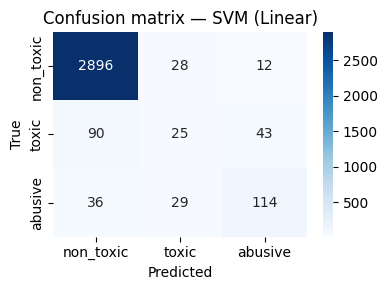

In [13]:
from sklearn.svm import LinearSVC

t0 = time.time()
svm = LinearSVC(C=1.0, class_weight="balanced", random_state=SEED)
svm.fit(X_train_tfidf, y_train)
fit_svm = time.time() - t0

y_pred_svm = svm.predict(X_test_tfidf)
evaluate("SVM (Linear)", y_test, y_pred_svm, fit_svm)


## 9. Model 3 — LSTM

A single LSTM layer on top of a learned embedding. Uses class weights to handle
the imbalance.


In [14]:
from sklearn.utils.class_weight import compute_class_weight
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Embedding, LSTM, Bidirectional, Dense, Dropout, GlobalMaxPooling1D
)
from tensorflow.keras.callbacks import EarlyStopping

NUM_CLASSES = 3
EMBED_DIM = 128

class_weights = compute_class_weight(
    class_weight="balanced", classes=np.unique(y_train), y=y_train
)
class_weight_dict = dict(enumerate(class_weights))
print("class weights:", class_weight_dict)


class weights: {0: np.float64(0.37164415236704396), 1: np.float64(6.877927927927928), 2: np.float64(6.102717825739409)}


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/5
120/120 - 10s - 83ms/step - accuracy: 0.7292 - loss: 0.9257 - val_accuracy: 0.8053 - val_loss: 0.6221
Epoch 2/5
120/120 - 2s - 13ms/step - accuracy: 0.8608 - loss: 0.5941 - val_accuracy: 0.8490 - val_loss: 0.3764
Epoch 3/5
120/120 - 2s - 14ms/step - accuracy: 0.9103 - loss: 0.3833 - val_accuracy: 0.8591 - val_loss: 0.4039
Epoch 4/5
120/120 - 2s - 15ms/step - accuracy: 0.9413 - loss: 0.2326 - val_accuracy: 0.8545 - val_loss: 0.4295

=== LSTM ===
              precision    recall  f1-score   support

   non_toxic       0.98      0.89      0.93      2936
       toxic       0.19      0.51      0.27       158
     abusive       0.64      0.66      0.65       179

    accuracy                           0.86      3273
   macro avg       0.60      0.69      0.62      3273
weighted avg       0.93      0.86      0.89      3273



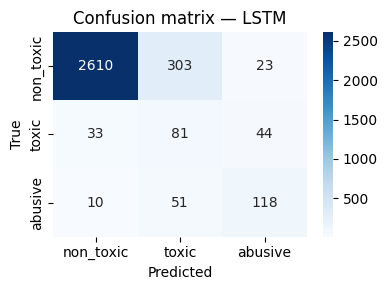

In [15]:
def build_lstm():
    model = Sequential([
        Embedding(VOCAB_SIZE, EMBED_DIM, input_length=MAX_LEN, mask_zero=True),
        LSTM(64, dropout=0.3, recurrent_dropout=0.0),
        Dense(64, activation="relu"),
        Dropout(0.3),
        Dense(NUM_CLASSES, activation="softmax"),
    ])
    model.compile(optimizer="adam",
                  loss="sparse_categorical_crossentropy",
                  metrics=["accuracy"])
    return model

lstm_model = build_lstm()
lstm_model.summary()

es = EarlyStopping(monitor="val_loss", patience=2, restore_best_weights=True)

t0 = time.time()
history_lstm = lstm_model.fit(
    X_train_pad, y_train,
    validation_data=(X_val_pad, y_val),
    epochs=5, batch_size=128,
    class_weight=class_weight_dict,
    callbacks=[es],
    verbose=2,
)
fit_lstm = time.time() - t0

y_pred_lstm = lstm_model.predict(X_test_pad, verbose=0).argmax(axis=1)
evaluate("LSTM", y_test, y_pred_lstm, fit_lstm)


## 10. Model 4 — BiLSTM

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_max_pooling1d            │ ?                      │             0 │
│ (GlobalMaxPooling1D)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/5
120/120 - 6s - 49ms/step - accuracy: 0.7097 - loss: 0.9249 - val_accuracy: 0.7952 - val_loss: 0.6342
Epoch 2/5
120/120 - 2s - 20ms/step - accuracy: 0.8811 - loss: 0.5773 - val_accuracy: 0.8710 - val_loss: 0.3554
Epoch 3/5
120/120 - 2s - 20ms/step - accuracy: 0.9186 - loss: 0.3830 - val_accuracy: 0.9010 - val_loss: 0.3102
Epoch 4/5
120/120 - 3s - 26ms/step - accuracy: 0.9474 - loss: 0.2199 - val_accuracy: 0.8765 - val_loss: 0.4896
Epoch 5/5
120/120 - 4s - 37ms/step - accuracy: 0.9688 - loss: 0.1431 - val_accuracy: 0.8457 - val_loss: 0.5780

=== BiLSTM ===
              precision    recall  f1-score   support

   non_toxic       0.97      0.95      0.96      2936
       toxic       0.25      0.42      0.31       158
     abusive       0.68      0.55      0.61       179

    accuracy                           0.90      3273
   macro avg       0.63      0.64      0.63      3273
weighted avg       0.92      0.90      0.91      3273



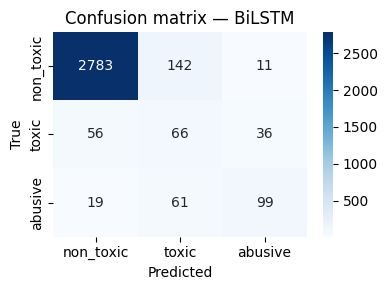

In [16]:
def build_bilstm():
    model = Sequential([
        Embedding(VOCAB_SIZE, EMBED_DIM, input_length=MAX_LEN, mask_zero=True),
        Bidirectional(LSTM(64, return_sequences=True, dropout=0.3)),
        GlobalMaxPooling1D(),
        Dense(64, activation="relu"),
        Dropout(0.3),
        Dense(NUM_CLASSES, activation="softmax"),
    ])
    model.compile(optimizer="adam",
                  loss="sparse_categorical_crossentropy",
                  metrics=["accuracy"])
    return model

bilstm_model = build_bilstm()
bilstm_model.summary()

es = EarlyStopping(monitor="val_loss", patience=2, restore_best_weights=True)

t0 = time.time()
history_bilstm = bilstm_model.fit(
    X_train_pad, y_train,
    validation_data=(X_val_pad, y_val),
    epochs=5, batch_size=128,
    class_weight=class_weight_dict,
    callbacks=[es],
    verbose=2,
)
fit_bilstm = time.time() - t0

y_pred_bilstm = bilstm_model.predict(X_test_pad, verbose=0).argmax(axis=1)
evaluate("BiLSTM", y_test, y_pred_bilstm, fit_bilstm)


## 11. ROC Curves (one-vs-rest)

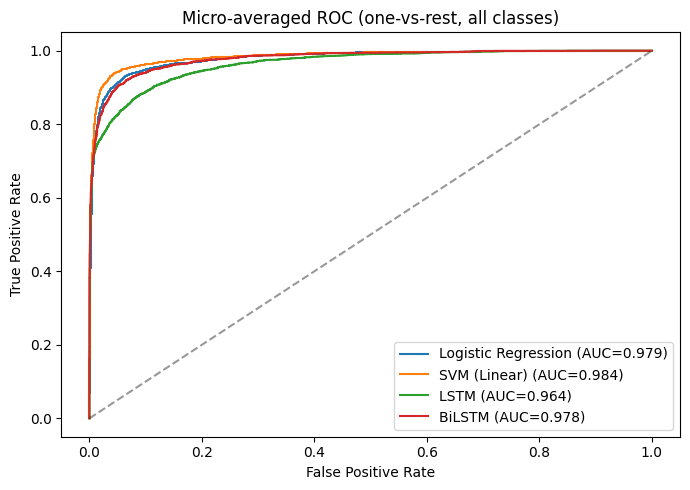

In [17]:
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize

y_test_bin = label_binarize(y_test, classes=[0, 1, 2])

def get_scores(model, X, kind):
    if kind == "sklearn_proba":
        return model.predict_proba(X)
    if kind == "sklearn_decision":
        d = model.decision_function(X)
        # softmax-style normalisation for plotting
        e = np.exp(d - d.max(axis=1, keepdims=True))
        return e / e.sum(axis=1, keepdims=True)
    if kind == "keras":
        return model.predict(X, verbose=0)
    raise ValueError(kind)

scores = {
    "Logistic Regression": get_scores(logreg, X_test_tfidf, "sklearn_proba"),
    "SVM (Linear)":        get_scores(svm,    X_test_tfidf, "sklearn_decision"),
    "LSTM":                get_scores(lstm_model,   X_test_pad, "keras"),
    "BiLSTM":              get_scores(bilstm_model, X_test_pad, "keras"),
}

plt.figure(figsize=(7, 5))
for name, s in scores.items():
    fpr, tpr, _ = roc_curve(y_test_bin.ravel(), s.ravel())
    plt.plot(fpr, tpr, label=f"{name} (AUC={auc(fpr, tpr):.3f})")

plt.plot([0, 1], [0, 1], "k--", alpha=0.4)
plt.xlabel("False Positive Rate"); plt.ylabel("True Positive Rate")
plt.title("Micro-averaged ROC (one-vs-rest, all classes)")
plt.legend(); plt.tight_layout(); plt.show()


## 12. Final Comparison Table

In [18]:
results_df = pd.DataFrame(results).T[["Accuracy", "Precision", "Recall", "F1", "TrainTime(s)"]]
results_df = results_df.round(4)
results_df.to_csv("results_summary.csv")
results_df


,Accuracy,Precision,Recall,F1,TrainTime(s)
Logistic Regression,0.9096,0.6150,0.6491,0.6307,2.9014
SVM (Linear),0.9273,0.6459,0.5938,0.6119,0.4138
LSTM,0.8582,0.6026,0.6869,0.6185,15.0799
BiLSTM,0.9007,0.6324,0.6396,0.6263,18.2856


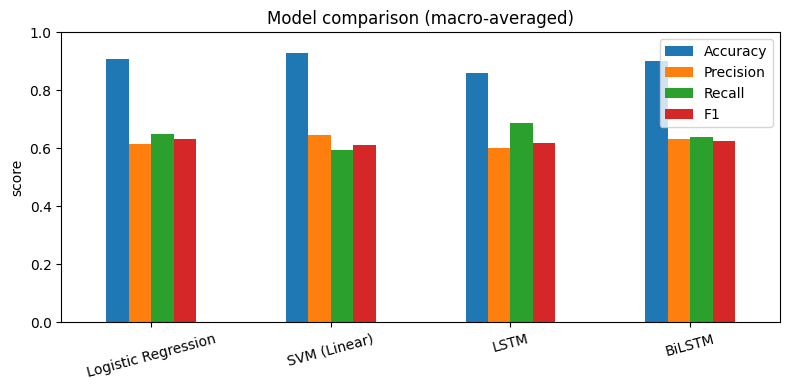

In [19]:
ax = results_df[["Accuracy", "Precision", "Recall", "F1"]].plot(
    kind="bar", figsize=(8, 4))
ax.set_title("Model comparison (macro-averaged)")
ax.set_ylabel("score")
ax.set_ylim(0, 1)
plt.xticks(rotation=15)
plt.tight_layout(); plt.show()


## 13. Discussion

* **Logistic Regression** is the cheapest and surprisingly strong on TF-IDF features — a hard baseline to beat for short text.
* **SVM (LinearSVC)** typically improves precision on the minority *abusive* class but trains slower than logistic regression.
* **LSTM** captures word order and lifts recall on the toxic classes, at the cost of significantly longer training.
* **BiLSTM** with global max-pooling usually gives the best macro-F1 because it sees both directions of context — the right model when you can afford GPU training.

**Limitations**

* Datasets are imbalanced — even with class-weights, the *abusive* class has the fewest training examples.
* Slang, sarcasm, and code-mixed text remain hard for all four models.
* Word-level models miss sub-word signal; a transformer (BERT) would be the natural next step.

---
*End of notebook.*
